In [1]:
import pypsa
import matplotlib.pyplot as plt

In [79]:
n = pypsa.Network("base_s_25.nc")

INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, lines, links


In [58]:
n.buses.index

Index(['BE1 0', 'DE1 0', 'DE1 1', 'DE1 2', 'DE1 3', 'DE1 4', 'DE1 5', 'DK1 0',
       'DK3 0', 'FR1 0', 'FR1 1', 'FR1 2', 'FR1 3', 'FR1 4', 'FR1 5', 'FR1 6',
       'FR1 7', 'GB0 0', 'GB0 1', 'GB0 2', 'GB0 3', 'GB2 0', 'IE2 0', 'LU1 0',
       'NL1 0', 'PEI', 'DKOH', 'DEOH', 'NLOH'],
      dtype='object', name='Bus')

In [80]:
n.add("Bus","PEI")
n.buses.loc["PEI", ["x", "y"]] = [2.706047, 51.466411]
n.add("Bus", "DKOH")
n.buses.loc["DKOH", ["x", "y"]] = [5.991189, 56.185492]
#n.add("Bus", "DEOH")
#n.buses.loc["DEOH", ["x", "y"]] = [6.236433, 54.812295]
n.add("Bus", "NLOH")
n.buses.loc["NLOH", ["x", "y"]] = [3.939687, 54.126002]

In [81]:
n.add("Link","Nautilus BE", bus0="PEI",bus1="BE1 0",p_nom=1400.0,efficiency=1,carrier="DC", p_min_pu = -1.0)
n.add("Link","Nautilus GB", bus0="PEI",bus1="GB0 2",p_nom=1400.0,efficiency=1,carrier="DC", p_min_pu = -1.0)

n.add("Link","Lionlink NL", bus0="NLOH",bus1="NL1 0",p_nom=1400.0,efficiency=1,carrier="DC", p_min_pu = -1.0)
n.add("Link","Lionlink GB", bus0="NLOH",bus1="GB0 3",p_nom=1400.0,efficiency=1,carrier="DC", p_min_pu = -1.0)

n.add("Link","BEOH-DKOH", bus0="PEI",bus1="DKOH",p_nom=1400.0,efficiency=1,carrier="DC", p_min_pu = -1.0)
n.add("Link","DKOH-DK", bus0="DKOH",bus1="DK1 0",p_nom=1400.0,efficiency=1,carrier="DC", p_min_pu = -1.0)




Index(['DKOH-DK'], dtype='object')

In [ ]:
5.991189

/var/folders/cn/l4_9msnj2pb5tkz_l18sbgdh0000gn/T/ipykernel_10001/1088660505.py:2: DeprecatedWarning: plot is deprecated as of 0.34 and will be removed in 1.0. Use `n.plot.map()` as a drop-in replacement instead.
  n.plot(color_geomap = True, bus_colors = "#583B23", line_colors = "#EE8434" , link_colors = "#7F5A83")


{'nodes': {'Bus': <matplotlib.collections.PatchCollection at 0x1514d6b10>},
 'branches': {'Link': <matplotlib.collections.LineCollection at 0x1514d4190>,
  'Line': <matplotlib.collections.LineCollection at 0x1514ee550>},
 'flows': {}}

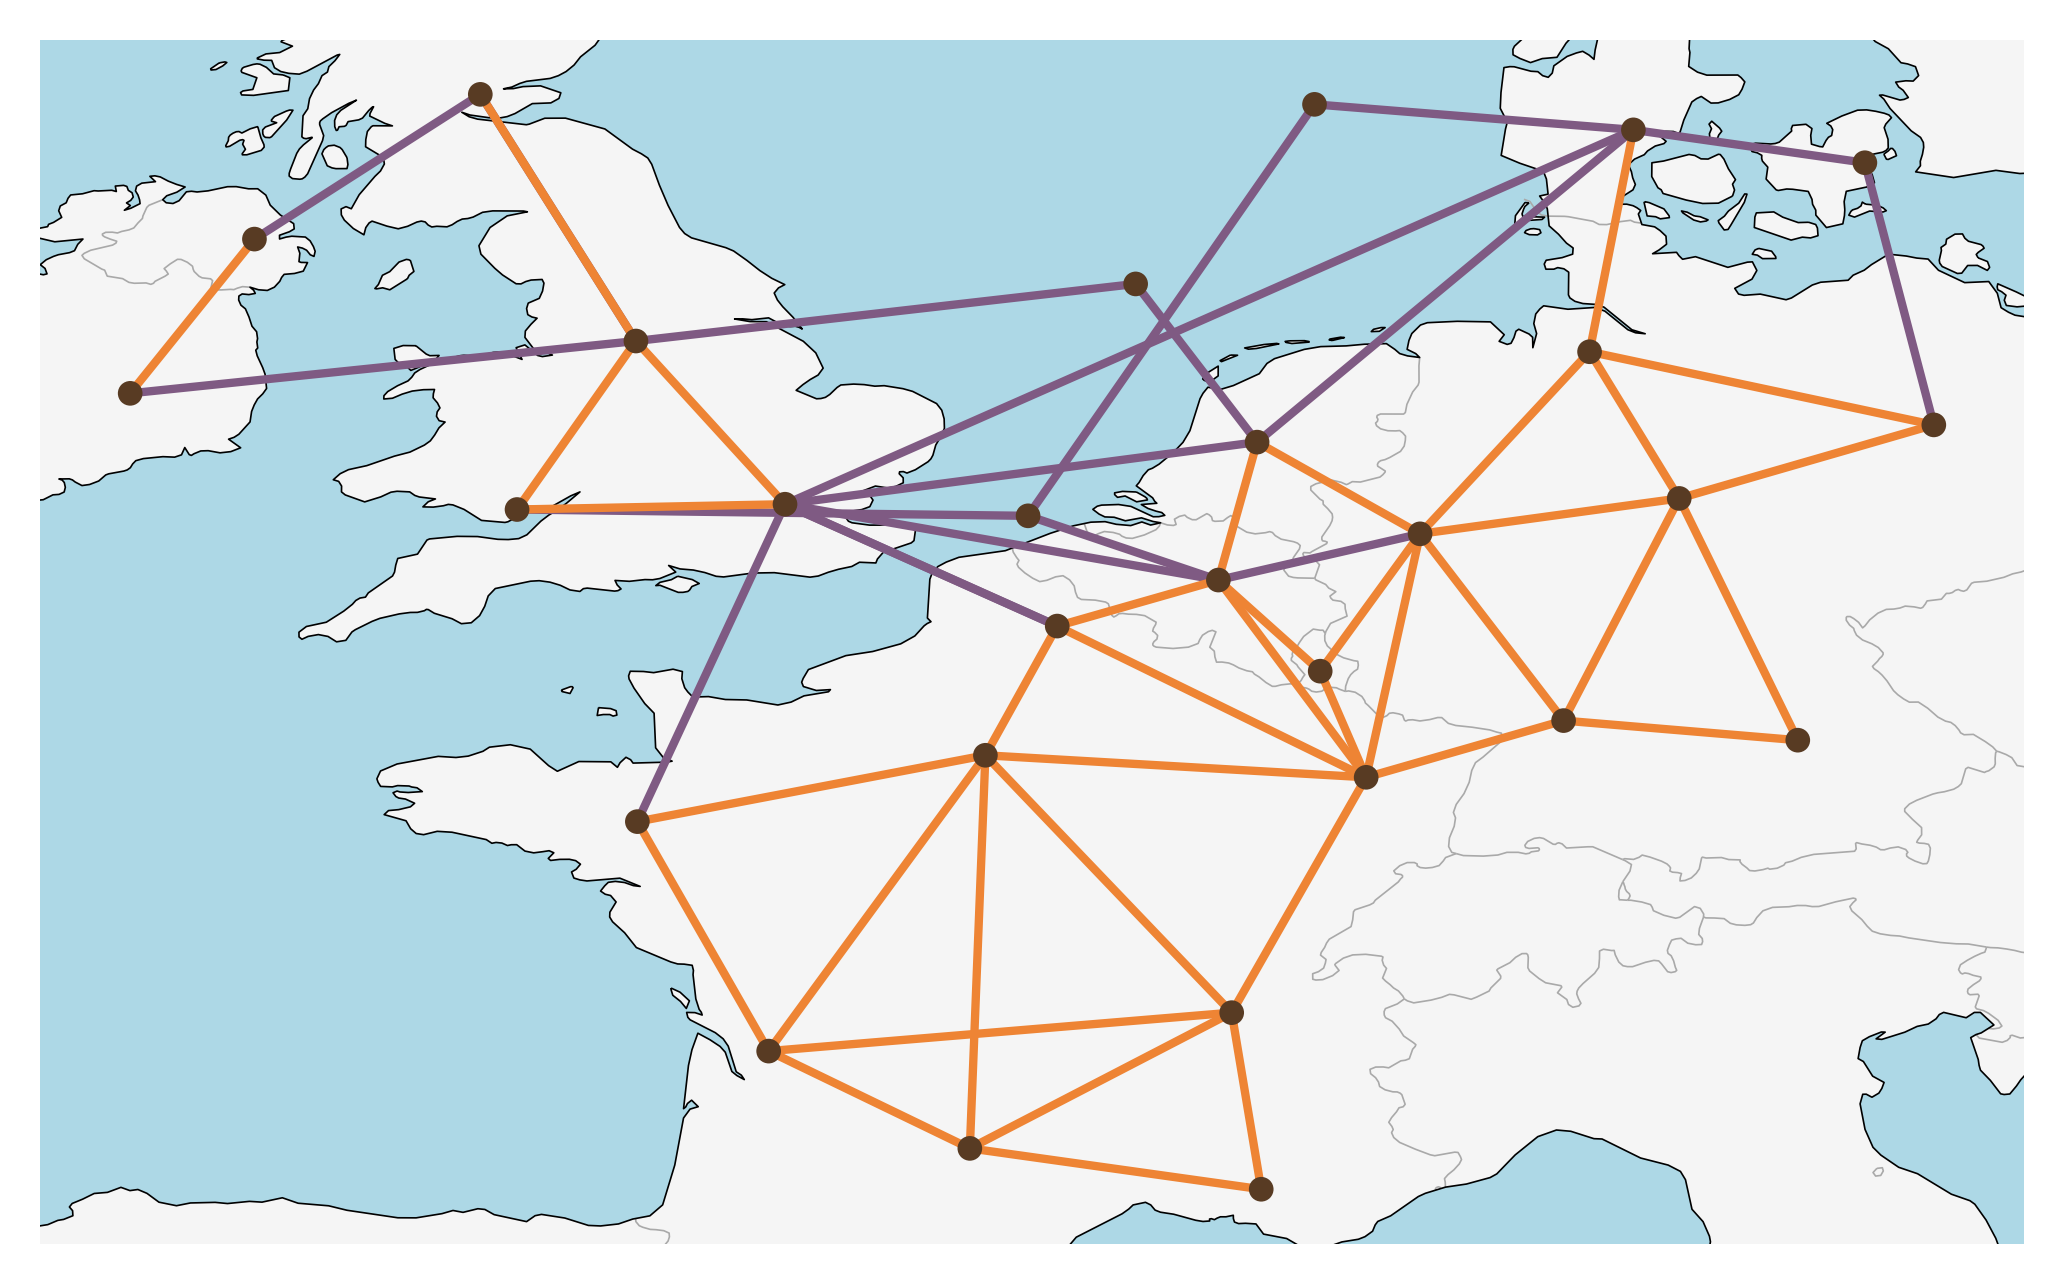

In [82]:
plt.figure(dpi=400)
n.plot(color_geomap = True, bus_colors = "#583B23", line_colors = "#EE8434" , link_colors = "#7F5A83")

In [ ]:
years = ["2030 (expected)", "2040 (needs)", "2050 (needs)"]
capacity = [161, 269, 385]
investments = [0, 6, 13]



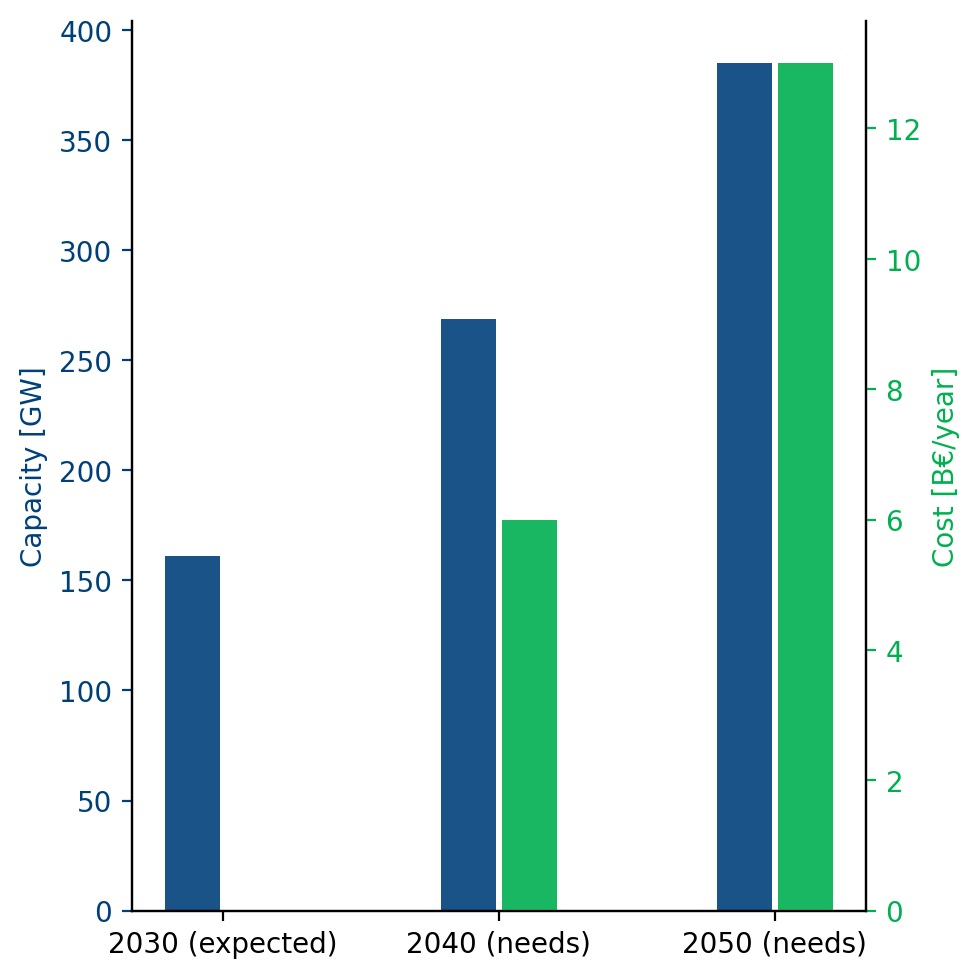

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Data
categories = ["2030 (expected)", "2040 (needs)", "2050 (needs)"]
y1 = [161, 269, 385]      # Primary axis
y2 = [0, 6, 13]     # Secondary axis

x = np.arange(len(categories))
width = 0.2

# Figure
fig, ax1 = plt.subplots(figsize=(5, 5), dpi=200)
ax2 = ax1.twinx()

# Bars
bars1 = ax1.bar(
    x - width/2 - width/20, y1, width,
    label="Capacity",
    color="#00407A",
    alpha=0.9
)

bars2 = ax2.bar(
    x + width/2 + width/20, y2, width,
    label="Cost",
    color="#00B050",
    alpha=0.9
)

# Labels
ax1.set_xticks(x)
ax1.set_xticklabels(categories)

ax1.set_ylabel("Capacity [GW]", color="#00407A")
ax2.set_ylabel("Cost [B€/year]", color="#00B050")

ax1.tick_params(axis='y', colors="#00407A")
ax2.tick_params(axis='y', colors="#00B050")

# Nice styling
#ax1.grid(axis="y", linestyle="--", alpha=0.3)
ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)

# Combined legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
#ax1.legend(handles1 + handles2, labels1 + labels2, frameon=False, loc="upper left")

#plt.title("No title")
plt.tight_layout()
plt.show()

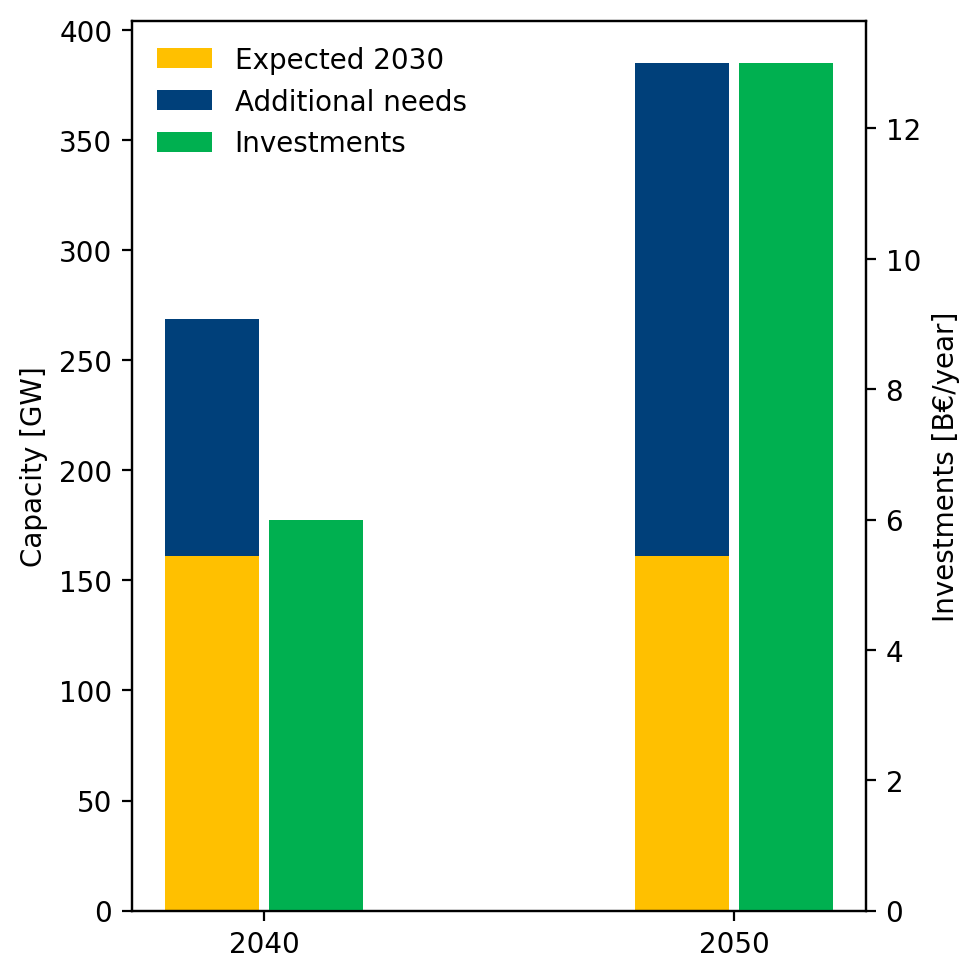

In [38]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(2)
labels = ["2040", "2050"]

# Primary axis quantities (stacked)
a = [161, 161]
b = [108,224]

# Secondary axis quantity
c = [6, 13]

width = 0.2

fig, ax1 = plt.subplots(figsize=(5, 5), dpi=200)
ax2 = ax1.twinx()

# Stacked bars on primary axis
ax1.bar(x - width/2 - width/20, a, width,
        color="#FFC000", label="Expected 2030")
ax1.bar(x - width/2 - width/20, b, width,
        bottom=a, color="#00407A", label="Additional needs")

# Secondary-axis bars
ax2.bar(x + width/2 + width/20, c, width,
        color="#00B050", label="Investments")

ax1.set_xticks(x)
ax1.set_xticklabels(labels)

ax1.set_ylabel("Capacity [GW]")
ax2.set_ylabel("Investments [B€/year]")

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, frameon=False, loc="upper left")

#ax1.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()